In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("telco_churn.csv")

# Basic inspection
df.info()
df.isna().sum()

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop any missing values
df = df.dropna()

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# Churn rate
churn_rate = df['Churn'].mean()
print(f"Churn Rate: {churn_rate:.2%}")

# Churn by contract type
df.groupby('Contract')['Churn'].mean().sort_values()


Churn Rate: 26.58%


Contract
Two year          0.028487
One year          0.112772
Month-to-month    0.427097
Name: Churn, dtype: float64

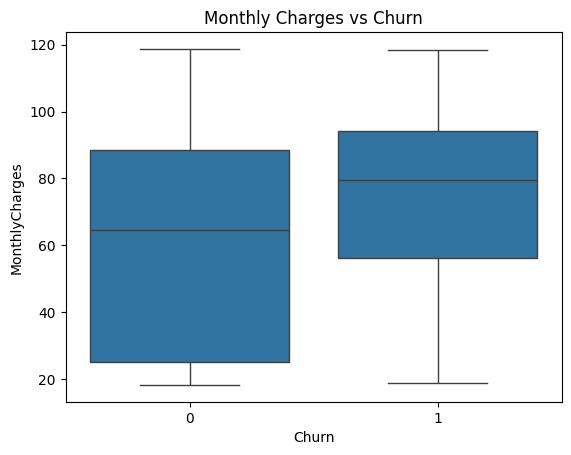

In [4]:
import seaborn as sns

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


In [5]:
# Tenure groups
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 yr', '1-2 yrs', '2-4 yrs', '4-6 yrs']
)

df.groupby('TenureGroup', observed=True)['Churn'].mean()

C:\Users\Daniel Amare\AppData\Local\Temp\ipykernel_12112\257552023.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TenureGroup')['Churn'].mean()


TenureGroup
0-1 yr     0.476782
1-2 yrs    0.287109
2-4 yrs    0.203890
4-6 yrs    0.095132
Name: Churn, dtype: float64

In [7]:
df.groupby('OnlineSecurity')['Churn'].mean()

OnlineSecurity
No                     0.417787
No internet service    0.074342
Yes                    0.146402
Name: Churn, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model accuracy:", model.score(X_test, y_test))


Model accuracy: 0.7867298578199052
